# Plan a Texas FEMA eBFE Breakout from Two Source Models

This notebook uses two real Lower Colorado–Cummins FEMA Base Level Engineering
(eBFE) projects and one real NOAA National Water Model v3 flowline. **NWM
feature 5789096** begins in `ALUM CREEK TRIBUTARY 9` and continues into coverage
provided by `ALUM CREEK`.

The objective here is not to silently splice HEC-RAS text. It is to build the
auditable plan needed before that write:

1. Catalog independent steady 1D projects in GeoParquet-ready tables.
2. Use model polygons to find extent candidates.
3. Confirm the corresponding RAS reach with cross-section intersections,
   station sequence, and a transparent centerline-offset limit.
4. Find the minimum-switch source chain along the directed network edge.
5. Show the shared coverage zone, provisional seam, and source cross sections
   that a later geometry assembler must reconcile.

The committed figures are visual evidence from the real Texas/FEMA geometries.
Notebook 235 demonstrates the complementary single-source operation: it writes,
runs, and compares a buffered breakout while preserving a stricter one-section-
overlap inundation export domain.


In [1]:
from pathlib import Path
import io
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
import pandas as pd
import requests
from IPython.display import display
from shapely.ops import nearest_points


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ras_commander
from ras_commander import RasBreakout1D, RasPrj

WORK_ROOT = REPO_ROOT / "working" / "236_multi_model_1d_breakout_planning"
ASSET_ROOT = REPO_ROOT / "examples" / "assets" / "236_multi_model_1d_breakout_planning"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

EBFE_MODEL_ROOT = Path(
    os.environ.get(
        "RAS_COMMANDER_EBFE_RAW_MODEL_ROOT",
        r"H:\Testing\eBFE Model Organization\Downloads"
        r"\12090301_Models_extracted\Model",
    )
)
SOURCE_GROUP = EBFE_MODEL_ROOT / "Alum Creek-Colorado River"
SOURCE_IDS = ("ALUM CREEK TRIBUTARY 9", "ALUM CREEK")
TARGET_EDGE_ID = "5789096"
PROJECT_CRS = "EPSG:2277"  # NAD83 / Texas Central (ftUS)
MAX_CENTERLINE_OFFSET_FT = 500.0

print(f"ras-commander: {ras_commander.__version__}")
print(f"Loaded from: {ras_commander.__file__}")
print(f"eBFE source group: {SOURCE_GROUP}")


ras-commander: 0.96.2
Loaded from: H:\Symphony\ras-commander\multi-model-breakout\ras_commander\__init__.py
eBFE source group: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Alum Creek-Colorado River


## 1. Build a source catalog—not a database

Each caller-defined source ID is attached to an independent `RasPrj`. The
catalog records the active plan, geometry and flow files, profile schema,
geometry hash, footprint, river centerline, and cross-section cut lines.

These 4.1-era projects have no RASMapper file or CRS in their geometry HDF, so
the documented Texas Central feet CRS is supplied explicitly. The fallback
footprint is the convex hull of the text geometry's centerline and cut lines.
The persisted catalog uses Parquet/GeoParquet rather than GeoPackage or SQLite.


In [2]:
source_models = {}
for source_id in SOURCE_IDS:
    model_folder = SOURCE_GROUP / source_id
    project_file = model_folder / f"{source_id}.prj"
    if not project_file.is_file():
        raise FileNotFoundError(
            f"Missing {project_file}. Set RAS_COMMANDER_EBFE_RAW_MODEL_ROOT "
            "to the extracted Lower Colorado–Cummins Model directory."
        )
    ras = RasPrj()
    ras.initialize(
        model_folder,
        "Ras.exe",
        suppress_logging=True,
        load_results_summary=False,
        load_hdf_metadata=False,
    )
    source_models[source_id] = ras

catalog = RasBreakout1D.catalog_sources(
    source_models,
    analysis_crs=PROJECT_CRS,
)
catalog_path = catalog.write(WORK_ROOT / "source_catalog", overwrite=True)

assert catalog.summary == {
    "source_models": 2,
    "included_models": 2,
    "duplicate_models": 0,
    "reaches": 2,
    "cross_sections": 232,
}
display(pd.DataFrame([catalog.summary]))
display(
    catalog.models_df[[
        "geometry_id", "plan_number", "profile_count", "profile_names",
        "geometry_sha256", "included",
    ]]
)
print(f"GeoParquet catalog: {catalog_path}")


2026-09-03 10:14:33 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Alum Creek-Colorado River\ALUM CREEK TRIBUTARY 9\ALUM CREEK TRIBUTARY 9.rasmap


2026-09-03 10:14:34 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Alum Creek-Colorado River\ALUM CREEK\ALUM CREEK.rasmap


,source_models,included_models,duplicate_models,reaches,cross_sections
0,2,2,0,2,232


,geometry_id,plan_number,profile_count,profile_names,geometry_sha256,included
0,ALUM CREEK,01,7,"(10-year, 25-year, 50-year, 1pct_min, 100-year...",851bc428621e0115681ec55ac0c52c175c28811a9cd989...,True
1,ALUM CREEK TRIBUTARY 9,01,7,"(10-year, 25-year, 50-year, 1pct_min, 100-year...",9a28518436f1088411ad4204b5b876fbf20207ba671819...,True


GeoParquet catalog: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\source_catalog


## 2. Plan directed coverage for the real NWM edge

The NOAA service returns the target flowline directly. Its coordinate order is
treated as upstream to downstream. Model polygons are only the candidate
filter; a source is accepted only when one reach has at least two intersecting
cross sections, decreasing RAS stations advance with edge measure, and its
sampled mean centerline offset is no more than 500 feet.

That 500-foot value is an explicit example parameter, not a hidden score. It is
large enough for the mapped eBFE/NWM offset at the downstream confluence and is
reported in the assignment table.


In [3]:
NWM_SERVICE = (
    "https://maps.water.noaa.gov/server/rest/services/"
    "reference/static_nwm_flowlines/FeatureServer/0/query"
)
nwm_cache = WORK_ROOT / f"nwm_{TARGET_EDGE_ID}.parquet"
if nwm_cache.is_file():
    target_edge = gpd.read_parquet(nwm_cache)
else:
    query = {
        "where": f"feature_id={TARGET_EDGE_ID}",
        "outFields": "feature_id,name,strm_order,huc6,nwm_vers",
        "returnGeometry": "true",
        "outSR": 4326,
        "f": "geojson",
    }
    response = requests.get(NWM_SERVICE, params=query, timeout=60)
    response.raise_for_status()
    target_edge = gpd.read_file(io.BytesIO(response.content))
    target_edge["feature_id"] = target_edge["feature_id"].astype(str)
    target_edge.to_parquet(nwm_cache, index=False)
target_edge = target_edge.to_crs(PROJECT_CRS)
assert target_edge["feature_id"].astype(str).eq(TARGET_EDGE_ID).all()

plan = RasBreakout1D.plan_network_edge(
    catalog,
    target_edge,
    edge_id=TARGET_EDGE_ID,
    adapter="nwm",
    max_centerline_offset=MAX_CENTERLINE_OFFSET_FT,
)

plan_row = plan.coverage_plan.plans_df.iloc[0]
assert plan.status == "multi_source_ready"
assert plan_row["source_geometry_ids"] == SOURCE_IDS
assert plan_row["coverage_fraction"] == 1.0
assert plan.seams_df.iloc[0]["relationship"] == "overlap"

display(
    plan.reach_assignments_df.drop(columns="geometry").style.format({
        "xs_measure_start": "{:.0f}",
        "xs_measure_end": "{:.0f}",
        "centerline_offset_mean": "{:.1f}",
    })
)
display(plan.coverage_plan.plans_df.drop(columns="geometry"))
display(plan.source_slices_df.drop(columns="geometry"))
display(plan.seams_df.drop(columns="geometry"))


,geometry_id,edge_id,reach_id,river,reach,xs_intersection_count,xs_measure_start,xs_measure_end,xs_sequence,centerline_offset_mean,status,reason_codes
0,ALUM CREEK TRIBUTARY 9,5789096,ALUM CREEK TRIBUTARY 9::ALUM CREEK TRIBU::Reach-1,ALUM CREEK TRIBU,Reach-1,11,33,4287,with_edge,97.1,confirmed,()
1,ALUM CREEK,5789096,ALUM CREEK::ALUM CREEK::Reach-1,ALUM CREEK,Reach-1,5,4198,6609,with_edge,464.2,confirmed,()


,edge_id,status,edge_length,selected_model_count,selected_slice_count,source_geometry_ids,source_slice_geometry_ids,covered_length,coverage_fraction,total_gap_length,maximum_gap_length,fully_covered,orientation_source
0,5789096,multi_source_ready,6962.261191,2,2,"(ALUM CREEK TRIBUTARY 9, ALUM CREEK)","(ALUM CREEK TRIBUTARY 9, ALUM CREEK)",6962.261191,1.0,0.0,0.0,True,edge_coordinate_order


,edge_id,source_order,geometry_id,coverage_start,coverage_end,retained_start,retained_end,retained_length
0,5789096,0,ALUM CREEK TRIBUTARY 9,0.000000,5059.809331,0.000000,3981.552868,3981.552868
1,5789096,1,ALUM CREEK,2903.296405,6962.261191,3981.552868,6962.261191,2980.708323


,edge_id,seam_index,upstream_geometry_id,downstream_geometry_id,relationship,overlap_start,overlap_end,overlap_length,gap_length,seam_measure,seam_fraction
0,5789096,0,ALUM CREEK TRIBUTARY 9,ALUM CREEK,overlap,2903.296405,5059.809331,2156.512926,0.0,3981.552868,0.571876


## 3. Visual proof: extents find candidates; geometry confirms them

The first panel shows why the two model polygons are sufficient for coverage
measurement. The second panel supplies the hydraulic evidence: independently
parsed RAS centerlines and cross-section cut lines follow the same directed NWM
edge. The magenta point is the midpoint of the shared **footprint** interval;
it is deliberately labeled provisional.


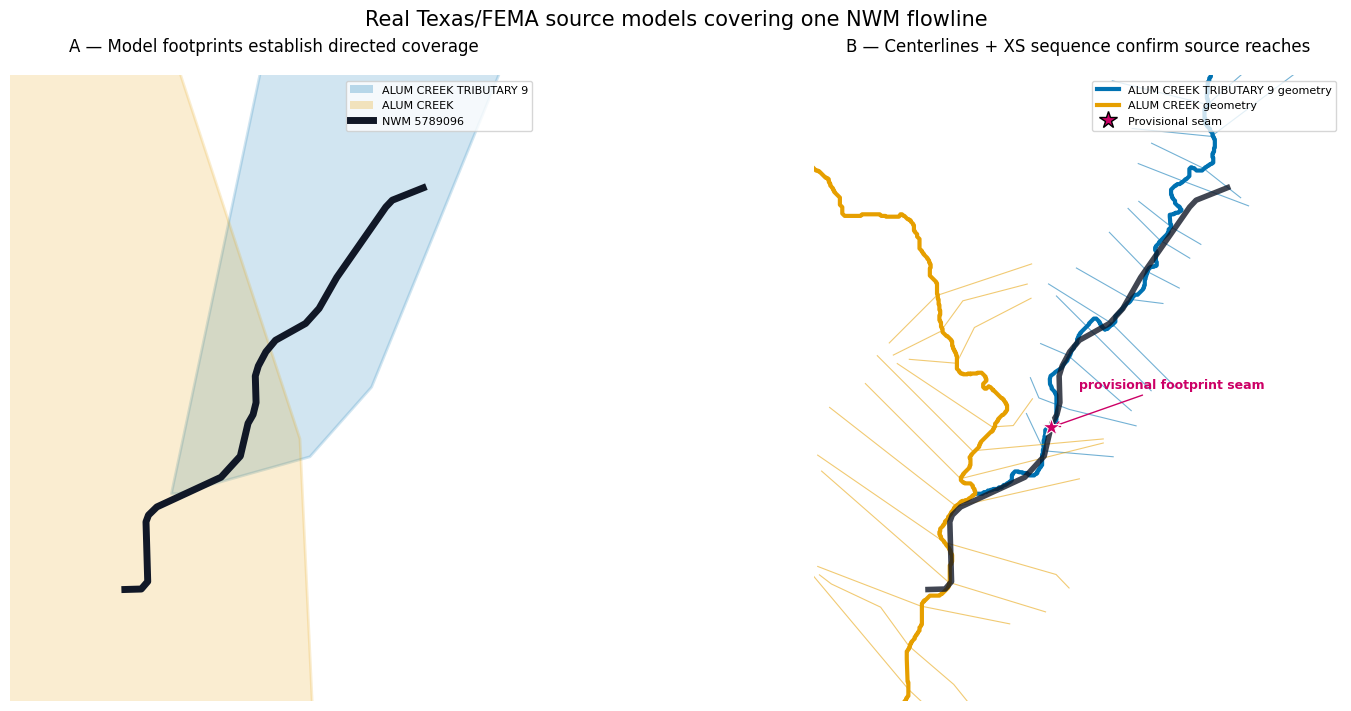

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\01_extent_and_geometry_confirmation.png


In [4]:
colors = {
    "ALUM CREEK TRIBUTARY 9": "#0072B2",
    "ALUM CREEK": "#E69F00",
}
edge_geometry = target_edge.geometry.iloc[0]
seam = plan.seams_df.iloc[0]
focus = edge_geometry.buffer(1400.0)

confirmed = plan.reach_assignments_df.loc[
    plan.reach_assignments_df["status"] == "confirmed"
]
confirmed_reach_ids = set(confirmed["reach_id"])
confirmed_centerlines = catalog.centerlines_gdf.loc[
    catalog.centerlines_gdf["reach_id"].isin(confirmed_reach_ids)
]
confirmed_xs = catalog.cross_sections_gdf.loc[
    catalog.cross_sections_gdf["reach_id"].isin(confirmed_reach_ids)
    & catalog.cross_sections_gdf.intersects(focus)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
for source_id in SOURCE_IDS:
    footprint = catalog.footprints_gdf.loc[
        catalog.footprints_gdf["geometry_id"] == source_id
    ]
    footprint.plot(
        ax=axes[0], color=colors[source_id], edgecolor=colors[source_id],
        alpha=0.18, linewidth=2,
    )
target_edge.plot(ax=axes[0], color="#111827", linewidth=5)

for source_id in SOURCE_IDS:
    confirmed_centerlines.loc[
        confirmed_centerlines["geometry_id"] == source_id
    ].plot(ax=axes[1], color=colors[source_id], linewidth=3)
    confirmed_xs.loc[
        confirmed_xs["geometry_id"] == source_id
    ].plot(ax=axes[1], color=colors[source_id], linewidth=0.8, alpha=0.55)
target_edge.plot(ax=axes[1], color="#111827", linewidth=4, alpha=0.8)
plan.seams_df.plot(
    ax=axes[1], color="#CC0066", marker="*", markersize=180,
    edgecolor="white", linewidth=0.8, zorder=10,
)

for ax in axes:
    xmin, ymin, xmax, ymax = focus.bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
axes[0].set_title("A — Model footprints establish directed coverage")
axes[1].set_title("B — Centerlines + XS sequence confirm source reaches")
axes[1].annotate(
    "provisional footprint seam",
    (seam.geometry.x, seam.geometry.y),
    xytext=(20, 28), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#CC0066"},
    color="#CC0066", fontsize=9, fontweight="bold",
)
axes[0].legend(
    handles=[
        Patch(facecolor=colors[source_id], alpha=0.25, label=source_id)
        for source_id in SOURCE_IDS
    ] + [Line2D([0], [0], color="#111827", linewidth=5, label=f"NWM {TARGET_EDGE_ID}")],
    loc="best", fontsize=8,
)
axes[1].legend(
    handles=[
        Line2D([0], [0], color=colors[source_id], linewidth=3, label=f"{source_id} geometry")
        for source_id in SOURCE_IDS
    ] + [Line2D([0], [0], marker="*", color="none", markerfacecolor="#CC0066", markersize=13, label="Provisional seam")],
    loc="best", fontsize=8,
)
fig.suptitle("Real Texas/FEMA source models covering one NWM flowline", fontsize=15)
figure_1 = ASSET_ROOT / "01_extent_and_geometry_confirmation.png"
fig.savefig(figure_1, dpi=180, bbox_inches="tight")
plt.show()
print(figure_1)


![Real Texas/FEMA source footprints and hydraulic geometry confirmation](assets/236_multi_model_1d_breakout_planning/01_extent_and_geometry_confirmation.png)

## 4. Visual proof: the minimum-switch coverage chain

The upper ribbons show where each footprint covers the NWM edge. Their 2,157-ft
shared interval is a handoff search zone—not a reason to score seven unrelated
signals. The lower ribbon is the deterministic ownership plan: upstream source
until the midpoint, downstream source afterward. No coverage gap is hidden.


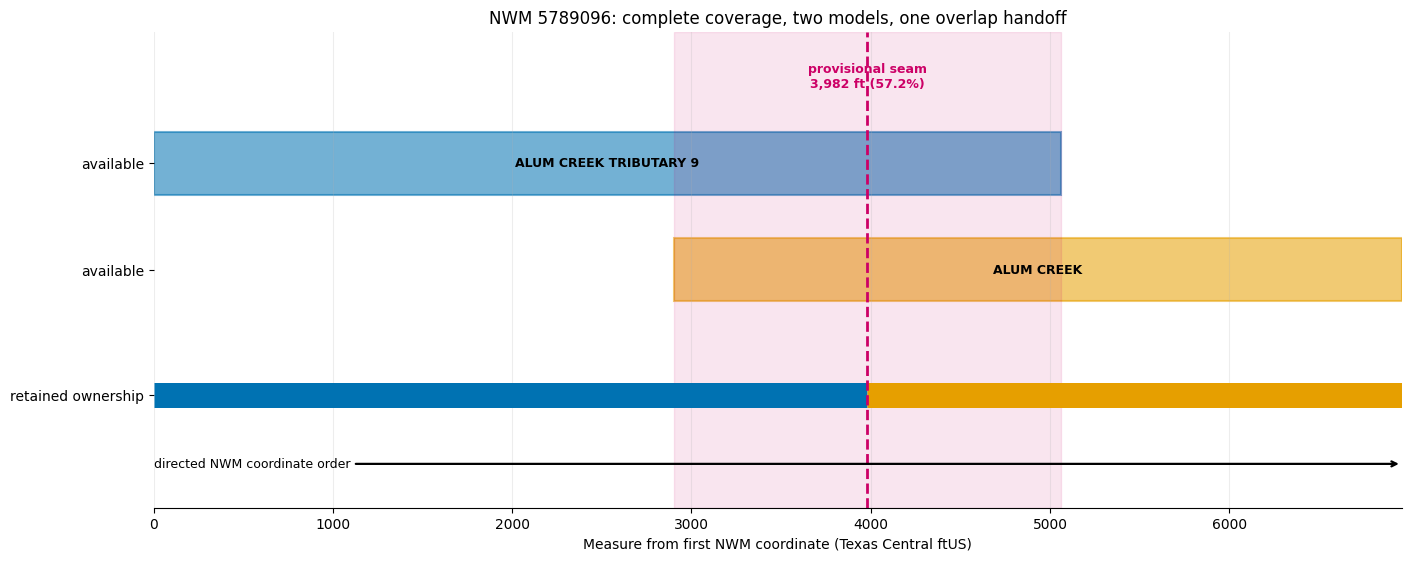

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\02_directed_coverage_chain.png


In [5]:
parts = plan.edge_coverage.coverage_parts_df.sort_values("coverage_start")
slices = plan.source_slices_df.sort_values("source_order")
edge_length = float(plan_row["edge_length"])
seam_measure = float(seam["seam_measure"])

fig, ax = plt.subplots(figsize=(14, 5.5), constrained_layout=True)
source_y = {SOURCE_IDS[0]: 2.2, SOURCE_IDS[1]: 1.35}
for row in parts.itertuples(index=False):
    ax.add_patch(Rectangle(
        (row.coverage_start, source_y[row.geometry_id] - 0.25),
        row.coverage_end - row.coverage_start, 0.5,
        facecolor=colors[row.geometry_id], alpha=0.55,
        edgecolor=colors[row.geometry_id], linewidth=1.5,
    ))
    ax.text(
        (row.coverage_start + row.coverage_end) / 2,
        source_y[row.geometry_id], row.geometry_id,
        ha="center", va="center", fontsize=9, fontweight="bold",
    )

overlap_start = float(seam["overlap_start"])
overlap_end = float(seam["overlap_end"])
ax.axvspan(overlap_start, overlap_end, color="#CC0066", alpha=0.10)
for row in slices.itertuples(index=False):
    ax.plot(
        [row.retained_start, row.retained_end], [0.35, 0.35],
        color=colors[row.geometry_id], linewidth=18, solid_capstyle="butt",
    )
ax.axvline(seam_measure, color="#CC0066", linestyle="--", linewidth=2)
ax.text(
    seam_measure, 2.78,
    f"provisional seam\n{seam_measure:,.0f} ft ({seam.seam_fraction:.1%})",
    ha="center", va="bottom", color="#CC0066", fontsize=9, fontweight="bold",
)
ax.annotate(
    "directed NWM coordinate order",
    xy=(edge_length, -0.2), xytext=(0, -0.2),
    arrowprops={"arrowstyle": "->", "linewidth": 1.6},
    va="center", fontsize=9,
)
ax.set_xlim(0, edge_length)
ax.set_ylim(-0.55, 3.25)
ax.set_yticks([2.2, 1.35, 0.35])
ax.set_yticklabels(["available", "available", "retained ownership"])
ax.set_xlabel("Measure from first NWM coordinate (Texas Central ftUS)")
ax.set_title(
    f"NWM {TARGET_EDGE_ID}: complete coverage, two models, one overlap handoff"
)
ax.grid(axis="x", alpha=0.22)
for side in ("left", "right", "top"):
    ax.spines[side].set_visible(False)
figure_2 = ASSET_ROOT / "02_directed_coverage_chain.png"
fig.savefig(figure_2, dpi=180, bbox_inches="tight")
plt.show()
print(figure_2)


![Directed model coverage intervals and provisional handoff](assets/236_multi_model_1d_breakout_planning/02_directed_coverage_chain.png)

## 5. Visual proof: which cross sections fall on each side of the handoff

This final map projects only directly intersecting cross sections onto the NWM
edge. Solid cut lines lie on the source's retained side of the provisional
handoff; dashed gray cut lines are present in that source but would cross the
other source's ownership interval. This is the precise conflict the geometry
assembler must resolve before it extends the upstream centerline and copies
complete downstream geometry blocks.


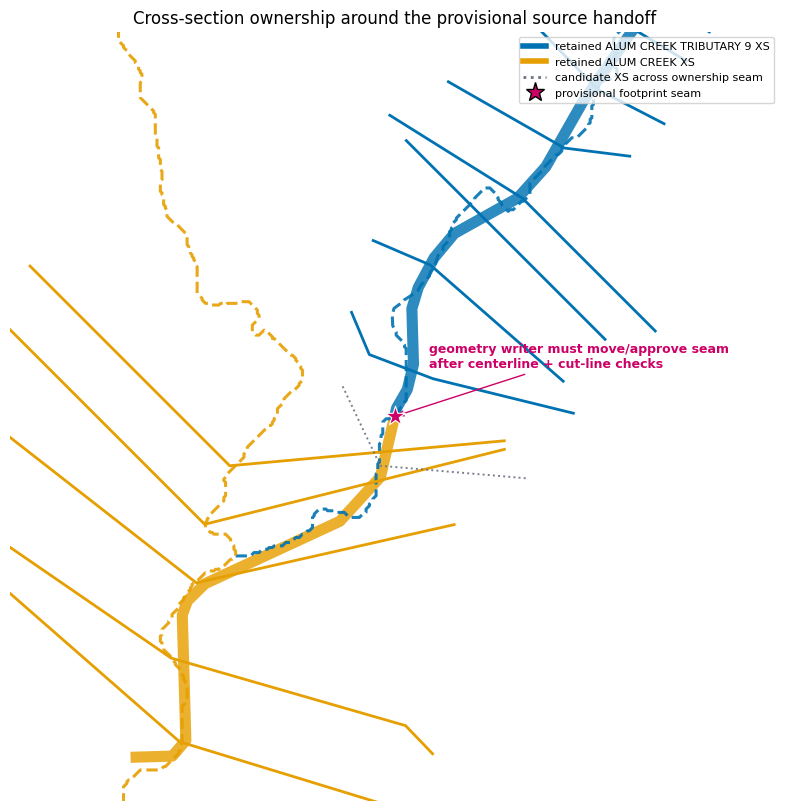

,geometry_id,station,edge_measure,retained_side
10,ALUM CREEK TRIBUTARY 9,6491,33,True
9,ALUM CREEK TRIBUTARY 9,6083,214,True
8,ALUM CREEK TRIBUTARY 9,5242,914,True
7,ALUM CREEK TRIBUTARY 9,5014,1129,True
6,ALUM CREEK TRIBUTARY 9,4497,1542,True
5,ALUM CREEK TRIBUTARY 9,4045,1955,True
4,ALUM CREEK TRIBUTARY 9,3628,2344,True
3,ALUM CREEK TRIBUTARY 9,3153,2595,True
2,ALUM CREEK TRIBUTARY 9,2692,3030,True
1,ALUM CREEK TRIBUTARY 9,1953,3687,True


H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\03_cross_section_ownership.png


In [6]:
assignment_by_source = confirmed.set_index("geometry_id")
xs_measure_rows = []
for source_id in SOURCE_IDS:
    reach_id = assignment_by_source.loc[source_id, "reach_id"]
    source_xs = catalog.cross_sections_gdf.loc[
        (catalog.cross_sections_gdf["reach_id"] == reach_id)
        & catalog.cross_sections_gdf.intersects(edge_geometry)
    ].copy()
    for row in source_xs.itertuples(index=False):
        edge_point, _ = nearest_points(edge_geometry, row.geometry)
        measure = float(edge_geometry.project(edge_point))
        retained = (
            measure <= seam_measure
            if source_id == SOURCE_IDS[0]
            else measure >= seam_measure
        )
        xs_measure_rows.append({
            "geometry_id": source_id,
            "station": row.station,
            "edge_measure": measure,
            "retained_side": retained,
            "geometry": row.geometry,
        })
xs_ownership = gpd.GeoDataFrame(
    xs_measure_rows, geometry="geometry", crs=PROJECT_CRS
).sort_values(["edge_measure", "geometry_id"])

fig, ax = plt.subplots(figsize=(12.5, 8), constrained_layout=True)
for row in slices.itertuples(index=False):
    gpd.GeoSeries([row.geometry], crs=PROJECT_CRS).plot(
        ax=ax, color=colors[row.geometry_id], linewidth=8, alpha=0.82,
    )
for source_id in SOURCE_IDS:
    centerline = confirmed_centerlines.loc[
        confirmed_centerlines["geometry_id"] == source_id
    ]
    centerline.plot(
        ax=ax, color=colors[source_id], linewidth=2.2, linestyle="--", alpha=0.9,
    )
    xs_ownership.loc[
        (xs_ownership["geometry_id"] == source_id)
        & xs_ownership["retained_side"]
    ].plot(ax=ax, color=colors[source_id], linewidth=2.0)
xs_ownership.loc[~xs_ownership["retained_side"]].plot(
    ax=ax, color="#6B7280", linewidth=1.4, linestyle=":", alpha=0.9,
)
plan.seams_df.plot(
    ax=ax, color="#CC0066", marker="*", markersize=220,
    edgecolor="white", linewidth=0.8, zorder=10,
)
seam_focus = seam.geometry.buffer(2300.0)
xmin, ymin, xmax, ymax = seam_focus.bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Cross-section ownership around the provisional source handoff")
ax.legend(
    handles=[
        Line2D([0], [0], color=colors[SOURCE_IDS[0]], linewidth=4, label=f"retained {SOURCE_IDS[0]} XS"),
        Line2D([0], [0], color=colors[SOURCE_IDS[1]], linewidth=4, label=f"retained {SOURCE_IDS[1]} XS"),
        Line2D([0], [0], color="#6B7280", linestyle=":", linewidth=2, label="candidate XS across ownership seam"),
        Line2D([0], [0], marker="*", color="none", markerfacecolor="#CC0066", markersize=14, label="provisional footprint seam"),
    ],
    loc="best", fontsize=8,
)
ax.annotate(
    "geometry writer must move/approve seam\nafter centerline + cut-line checks",
    (seam.geometry.x, seam.geometry.y),
    xytext=(25, 35), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#CC0066"},
    color="#CC0066", fontsize=9, fontweight="bold",
)
figure_3 = ASSET_ROOT / "03_cross_section_ownership.png"
fig.savefig(figure_3, dpi=180, bbox_inches="tight")
plt.show()

display(
    xs_ownership.drop(columns="geometry").style.format({"edge_measure": "{:.0f}"})
)
print(figure_3)


![Cross-section ownership around the provisional source handoff](assets/236_multi_model_1d_breakout_planning/03_cross_section_ownership.png)

## Result and next gate

For NWM 5789096, the extent union covers 100% of the 6,962-ft edge. Both source
reaches are confirmed, their cross-section stations advance consistently with
the NWM coordinate order, and the minimum-switch plan selects:

`ALUM CREEK TRIBUTARY 9 → ALUM CREEK`

The footprints overlap for about 2,157 ft, providing room to choose a stable
hydraulic splice instead of joining at a model boundary. The current output is
therefore a **ready source-coverage plan**, not a written combined HEC-RAS
geometry.

The geometry-writing increment should now:

- locate the first valid centerline intersection inside the overlap, or record
  and build the nearest defensible connector;
- retain the upstream source through that join and append only non-overlapping
  downstream cross-section/structure blocks;
- reconcile river/reach names, station identifiers, reach lengths, Manning's n,
  banks, levees, ineffective areas, HTAB data, profiles, flows, and boundaries;
- apply the existing 10% upstream / 25% downstream computation buffers at a
  fully-contained NWM target and preserve the existing one-cross-section strict
  inundation overlap; and
- write, run, validate, and compare the assembled project to both sources.

Notebook 235 is the executable reference for that final trim/run/result-
comparison contract. This notebook establishes the multi-model evidence and
handoff plan that it previously lacked.
